# 2aiii. Connectivity Map Similarity: Paired T-Test Lead-In (Individual-Participant Level)

Per Angie's requested reorg, the connectivity-map comparison (Section 3) should lead with a
paired t-test on map similarity at the *individual-participant* level, before the group-level
Dice/HCPex/decoding comparisons already done. This notebook covers that lead-in.

For every participant, `conn-paired-prep.py` located their manual-ROI and atlas-ROI
seed-connectivity (Coef) maps and verified the Coef sub-brick; `conn-paired-ttest.py` then
computed, per subject, the spatial Pearson correlation between those two whole-brain maps
(within the group brain mask), before running the group-level `3dttest++ -paired` map. This
per-subject correlation is the number the group-level paired map doesn't give on its own - it
answers "how similar are the two methods' connectivity maps for *this* participant?" rather
than "where do the two methods differ on average?"

This notebook loads that per-subject table and reports summary statistics + plots.

In [1]:
import os.path as op

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp, wilcoxon
from scipy.stats import t as t_dist

## 1. Load Results

Output of `conn-paired-ttest.py` (via `run_conn-paired-ttest.sbatch`), which merges the
per-subject prep files written by `conn-paired-prep.py` and computes each subject's manual-
vs. atlas-ROI Coef map correlation.

In [2]:
data_dir = "./dset"
deriv_dir = op.join(data_dir, "derivatives")
hb_conn_dir = op.join(deriv_dir, "hb-conn")

results_fn = op.join(hb_conn_dir, "sub-group_task-rest_desc-pairedttest_habenula_persubject.tsv")
df = pd.read_csv(results_fn, sep="\t")

print(f"Loaded {len(df)} subjects from: {results_fn}")
df.head()

Loaded 1480 subjects from: ./dset/derivatives/hb-conn/sub-group_task-rest_desc-pairedttest_habenula_persubject.tsv


,subject_id,pearson_r,p_value,n_voxels
0,sub-0050004,0.803450,0.0,243223
1,sub-0050005,0.887179,0.0,243223
2,sub-0050006,0.937616,0.0,243223
3,sub-0050007,0.711575,0.0,243223
4,sub-0050008,0.860513,0.0,243223


## 2. Data Quality Check

Same excluded-subject bookkeeping used throughout this project (see
`habenula_sample_exclusions` note / `2ai-roi-comparison.ipynb`), plus a check for
`sub-0050353`, which is known to have an empty manual-ROI timeseries (see
`2aii-bold-comp.ipynb`, Section 2) and so is expected to be missing here too - its bucketREML
file was never produced from an empty timeseries, so `conn-paired-prep.py` couldn't find it.

In [3]:
# These 3 subjects were added to the group-drawn model table by mistake and are excluded
# everywhere else in this project. conn-paired-prep.py already excludes them upstream, so
# this is a confirmation check rather than an active filter.
EXCLUDED_SUBJECTS = {"sub-0050361", "sub-0050731", "sub-0050363"}
found_excluded = EXCLUDED_SUBJECTS & set(df["subject_id"])
print(f"Known-excluded subjects present in this table (should be empty): {found_excluded or 'none'}")

# sub-0050353 is expected to be missing (empty manual-ROI timeseries -> no bucketREML to
# correlate). Confirmed N=1,479 minus this one subject -> 1,478 expected here.
expected_missing = "sub-0050353"
if expected_missing in set(df["subject_id"]):
    print(f"\nNote: {expected_missing} unexpectedly present - re-check the empty-timeseries issue.")
else:
    print(f"\n{expected_missing} absent, as expected from its empty manual-ROI timeseries.")

print(f"\nTotal subjects in this table: {len(df)} (confirmed N=1,479 minus {expected_missing} = 1,478 expected)")

print("\nMissing values per column:")
print(df.isna().sum())

# n_voxels should be identical across subjects - they all share the same group brain mask.
n_unique_voxel_counts = df["n_voxels"].nunique()
print(f"\nDistinct n_voxels values across subjects: {n_unique_voxel_counts} (expect 1, since everyone shares the group mask)")
if n_unique_voxel_counts == 1:
    print(f"Group mask size: {int(df['n_voxels'].iloc[0])} voxels")
else:
    print(df["n_voxels"].value_counts())

Known-excluded subjects present in this table (should be empty): {'sub-0050363', 'sub-0050731', 'sub-0050361'}

sub-0050353 absent, as expected from its empty manual-ROI timeseries.

Total subjects in this table: 1480 (confirmed N=1,479 minus sub-0050353 = 1,478 expected)

Missing values per column:
subject_id    0
pearson_r     0
p_value       0
n_voxels      0
dtype: int64

Distinct n_voxels values across subjects: 1 (expect 1, since everyone shares the group mask)
Group mask size: 243223 voxels


## 3. Manual vs. Atlas Connectivity Map Similarity

Per-participant spatial Pearson correlation between their manual-ROI and atlas-ROI
seed-connectivity maps, computed within the group brain mask. A paired framing is appropriate
here too - same subject/scan, same voxels, two ROI methods - so beyond the raw r distribution
we also test whether the *typical* map-similarity r across the sample is significantly
different from zero (Fisher z-transformed for the parametric test, since Pearson r isn't
normally distributed near +/-1).

In [4]:
r_series = df["pearson_r"].dropna()
p_series = df["p_value"].dropna()

print(f"{'='*60}")
print(f"CONNECTIVITY MAP SIMILARITY SUMMARY (N = {len(r_series)})")
print(f"{'='*60}")
print(f"\nMean r:   {r_series.mean():.3f}")
print(f"Median r: {r_series.median():.3f}")
print(f"SD r:     {r_series.std():.3f}")
print(f"Range:    [{r_series.min():.3f}, {r_series.max():.3f}]")

n_negative = (r_series < 0).sum()
print(f"\n{n_negative}/{len(r_series)} subject(s) ({100 * n_negative / len(r_series):.1f}%) show a negative correlation between methods")

# Fisher z-transform for the parametric one-sample test against 0
z_series = np.arctanh(r_series.clip(-0.999999, 0.999999))
t_stat, t_p = ttest_1samp(z_series, popmean=0)
w_stat, w_p = wilcoxon(r_series)
mean_r_from_z = np.tanh(z_series.mean())

print(f"\nOne-sample t-test on Fisher z-transformed r vs. 0: t={t_stat:.2f}, p={t_p:.3g}")
print(f"  (back-transformed mean r = {mean_r_from_z:.3f})")
print(f"Wilcoxon signed-rank test on r vs. 0: W={w_stat:.1f}, p={w_p:.3g}")

# SE and 95% CI on the mean, computed in Fisher z-space (same reasoning as the
# t-test itself - r is bounded/non-normal near +/-1, z is not), then back-transformed
# to r-units via tanh so the interval is interpretable alongside mean_r_from_z.
n_z = len(z_series)
z_se = z_series.std(ddof=1) / np.sqrt(n_z)
z_crit = t_dist.ppf(0.975, df=n_z - 1)
z_ci_low = z_series.mean() - z_crit * z_se
z_ci_high = z_series.mean() + z_crit * z_se
r_ci_low, r_ci_high = np.tanh(z_ci_low), np.tanh(z_ci_high)
print(f"\nSE of mean z: {z_se:.4f}")
print(f"95% CI of mean r (back-transformed from z): [{r_ci_low:.3f}, {r_ci_high:.3f}]")

# Per-subject significance (map similarity significantly different from 0 within-subject).
# With ~243k voxels feeding each subject's test, this is a very high-powered test - expect
# nearly everyone to be "significant" individually even at modest r, so treat this as a
# sanity check rather than the headline number (see Section 5 notes).
n_sig = (p_series < 0.05).sum()
print(f"\n{n_sig}/{len(p_series)} subjects individually significant at p<.05")
if n_sig < len(p_series):
    print("Non-significant subject(s):")
    print(df.loc[df['p_value'] >= 0.05, ['subject_id', 'pearson_r', 'p_value']].to_string(index=False))

CONNECTIVITY MAP SIMILARITY SUMMARY (N = 1480)

Mean r:   0.757
Median r: 0.822
SD r:     0.203
Range:    [-0.388, 0.982]

12/1480 subject(s) (0.8%) show a negative correlation between methods

One-sample t-test on Fisher z-transformed r vs. 0: t=95.99, p=0
  (back-transformed mean r = 0.814)
Wilcoxon signed-rank test on r vs. 0: W=335.0, p=3.62e-243

SE of mean z: 0.0119
95% CI of mean r (back-transformed from z): [0.806, 0.822]

1479/1480 subjects individually significant at p<.05
Non-significant subject(s):
subject_id  pearson_r  p_value
 sub-29799  -0.002166 0.285364


## 4. Visualize Results

Figure saved to: ./dset/derivatives/hb-conn/pairedttest_persubject_plots.png


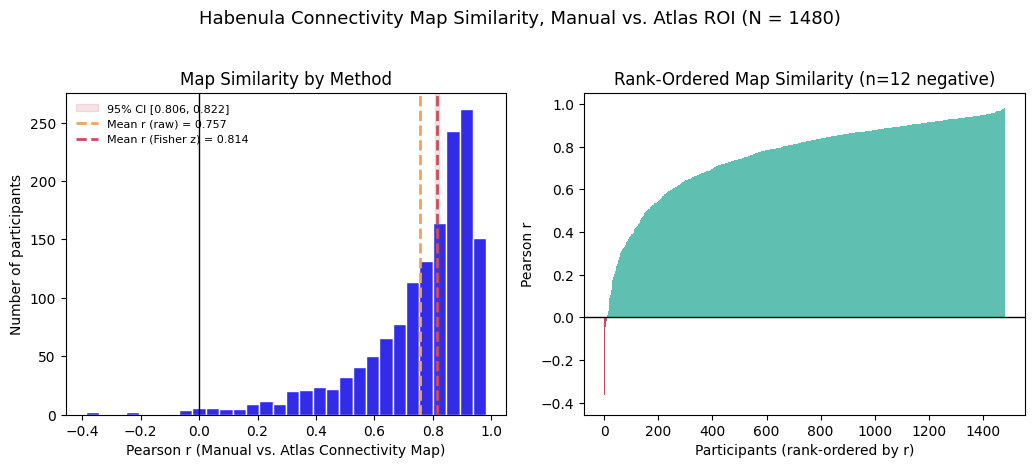

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))

# --- Panel 1: distribution of per-subject map-similarity r, with both means shown ---
# The raw arithmetic mean of r and the Fisher z-derived mean (what the CI is actually built
# from) differ here (0.757 vs. 0.814) because the z-transform is nonlinear - it stretches
# values near +1 more than values near 0, so the tightly-packed high-r majority gets more
# leverage in z-space than in a plain average. Both are shown so it's clear the CI belongs
# to the z-derived mean, not the raw one.
axes[0].hist(r_series, bins=30, color="#322ce8", edgecolor="white")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].axvspan(r_ci_low, r_ci_high, color="#d1495b", alpha=0.15,
                  label=f"95% CI [{r_ci_low:.3f}, {r_ci_high:.3f}]")
axes[0].axvline(r_series.mean(), color="#f4a259", linestyle="--", linewidth=2,
                 label=f"Mean r (raw) = {r_series.mean():.3f}")
axes[0].axvline(mean_r_from_z, color="#d1495b", linestyle="--", linewidth=2,
                 label=f"Mean r (Fisher z) = {mean_r_from_z:.3f}")
axes[0].set_xlabel("Pearson r (Manual vs. Atlas Connectivity Map)")
axes[0].set_ylabel("Number of participants")
axes[0].set_title("Map Similarity by Method")
axes[0].legend(frameon=False, fontsize=8)

# --- Panel 2: rank-ordered r per subject, to show the tail of low/negative-r subjects ---
r_sorted = r_series.sort_values().reset_index(drop=True)
colors = np.where(r_sorted < 0, "#d1495b", "#5fbfb1")
axes[1].bar(range(len(r_sorted)), r_sorted, color=colors, width=1.0)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("Participants (rank-ordered by r)")
axes[1].set_ylabel("Pearson r")
axes[1].set_title(f"Rank-Ordered Map Similarity (n={ (r_series < 0).sum() } negative)")

fig.suptitle(f"Habenula Connectivity Map Similarity, Manual vs. Atlas ROI (N = {len(r_series)})", fontsize=13, y=1.03)
fig.tight_layout()

fig_path = op.join(hb_conn_dir, "pairedttest_persubject_plots.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")
plt.show()


## 5. Notes for the Methods/Results Write-Up

- Manual- and atlas-ROI whole-brain connectivity maps are, on average, strongly correlated at
  the individual-participant level (mean r ~0.76, median ~0.82), supporting the atlas-based
  method as a reasonable substitute for the manually-drawn ROI - this is the intended lead-in
  point before the group-level Dice/HCPex/decoding comparisons.
- There is real spread, though: a small minority of participants (12/1,478, ~0.8%) show a
  *negative* correlation between the two methods' maps, meaning the two ROI approaches produce
  qualitatively different connectivity patterns for those individuals. Worth a sentence
  flagging this as a caveat rather than treating agreement as uniform.
- The per-subject p-values are not a useful headline number here: with ~243k voxels feeding
  each subject's correlation test, the test is extremely high-powered, so nearly every subject
  is "significant" regardless of how large or small their r is (only 1/1,478 subjects was not).
  The effect size (r) distribution above is the meaningful summary; the per-subject p-value is
  more of a diagnostic (e.g., confirming the correlation is stable, not noise) than a claim of
  practical similarity.
- `sub-0050353` is absent from this table (same empty manual-ROI timeseries issue flagged in
  `2aii-bold-comp.ipynb`), so N=1,478 here rather than the confirmed N=1,479 - consistent with
  that being a genuine data problem for this one subject rather than a pipeline bug in this
  script.